In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.signal import find_peaks
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import utils

In [22]:
HE_SHEET = "he test.xlsx"

# Load the data directly from the Google Sheet URL
df = pd.read_excel(HE_SHEET)

df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

print("DataFrame loaded successfully from Google Sheet. Here are the first 5 rows:")
print(df.head())

DataFrame loaded successfully from Google Sheet. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm  Unnamed: 3    Unnamed: 4  Unnamed: 5  \
0        2178   247.148  589.03701         NaN  max grey val         NaN   
1        2179   246.463  587.91075         NaN       247.148         NaN   
2        2180   243.830  586.78449         NaN           NaN         NaN   
3        2181   241.833  585.65823         NaN  min grey val         NaN   
4        2177   240.733  590.16327         NaN        16.674         NaN   

   Unnamed: 6 Unnamed: 7  
0  3042.03129   -1.12626  
1         NaN        NaN  
2         NaN        NaN  
3         NaN        NaN  
4         NaN    he_3584  


In [23]:
min_grey_val = df_filtered['Grey Val'].min()
max_grey_val = df_filtered['Grey Val'].max()
grey_val_range = max_grey_val - min_grey_val

In [24]:
rgb = utils.wavelength_to_rgb

Calculated dynamic prominence: 27.39


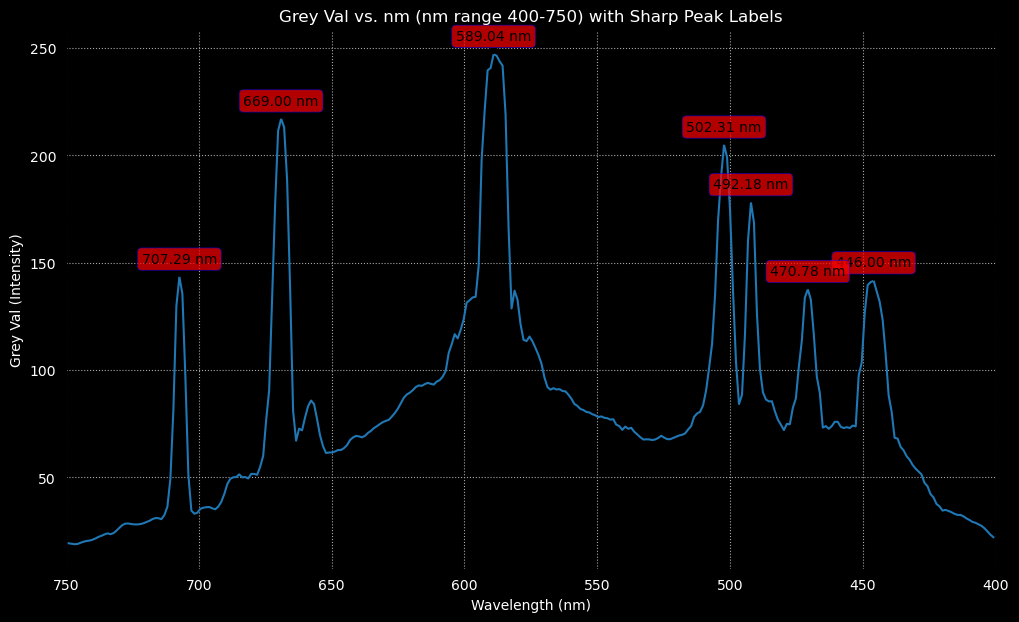

In [ ]:
# Filter the DataFrame for 'nm' values between 400 and 750
df_filtered = df[(df['nm'] >= 400) & (df['nm'] <= 750)].copy()

# Sort by 'nm' to ensure correct neighbor comparison and plotting order
df_filtered = df_filtered.sort_values(by='nm').reset_index(drop=True)

plt.figure(figsize=(12, 7))
sns.lineplot(data=df_filtered, x='nm', y='Grey Val', marker=None) # No markers
plt.title('Grey Val vs. nm (nm range 400-750) with Sharp Peak Labels', color='white')
plt.xlabel('nm')
plt.ylabel('Grey Val')
plt.grid(True, color='darkgrey', linestyle=':')

plt.xticks(color='white') # Set x-tick labels color to white
plt.yticks(color='white') # Set y-tick labels color to white
plt.xlabel('Wavelength (nm)', color='white') # Set x-label color to white
plt.ylabel('Grey Val (Intensity)', color='white') # Set y-label color to white

ax = plt.gca() # Get current axes
# Set background color to black
ax.set_facecolor('black')
plt.gcf().set_facecolor('black') # Set figure background color as well

# Set x-axis limits and reverse the order
plt.xlim(750, 400) # Set limits from 750 to 400, automatically reverses

# Define a prominence as a percentage of the overall range
# You will likely need to adjust this percentage (e.g., 0.05 for 5%, 0.1 for 10%)
# A higher percentage will be more selective, finding fewer, stronger peaks.
prominence_percentage = 0.12 # Increased to 0.12 to filter more aggressively
dynamic_prominence = prominence_percentage * grey_val_range

print(f"Calculated dynamic prominence: {dynamic_prominence:.2f}")
# Use scipy.signal.find_peaks to identify sharp peaks
# 'prominence' parameter helps in filtering stronger peaks (adjust as needed)
# A higher prominence value will select fewer, stronger peaks.
peaks, _ = find_peaks(df_filtered['Grey Val'], prominence=dynamic_prominence) # Using dynamic prominence

# Label the identified sharp peaks
for peak_index in peaks:
    row = df_filtered.iloc[peak_index]
    plt.annotate(f"{row['nm']:.2f} nm", # Formatted nm to two decimal places
                 (row['nm'], row['Grey Val']),
                 textcoords="offset points", # Offset the text
                 xytext=(0,10), # Distance from point to label
                 ha='center', # Horizontal alignment
                 bbox={"boxstyle": "round,pad=0.3", "fc": "red", "ec": "b", "lw": 0.5, "alpha": 0.7},
                 arrowprops=dict(facecolor='black', shrink=0.05))  # noqa: C408

plt.show()

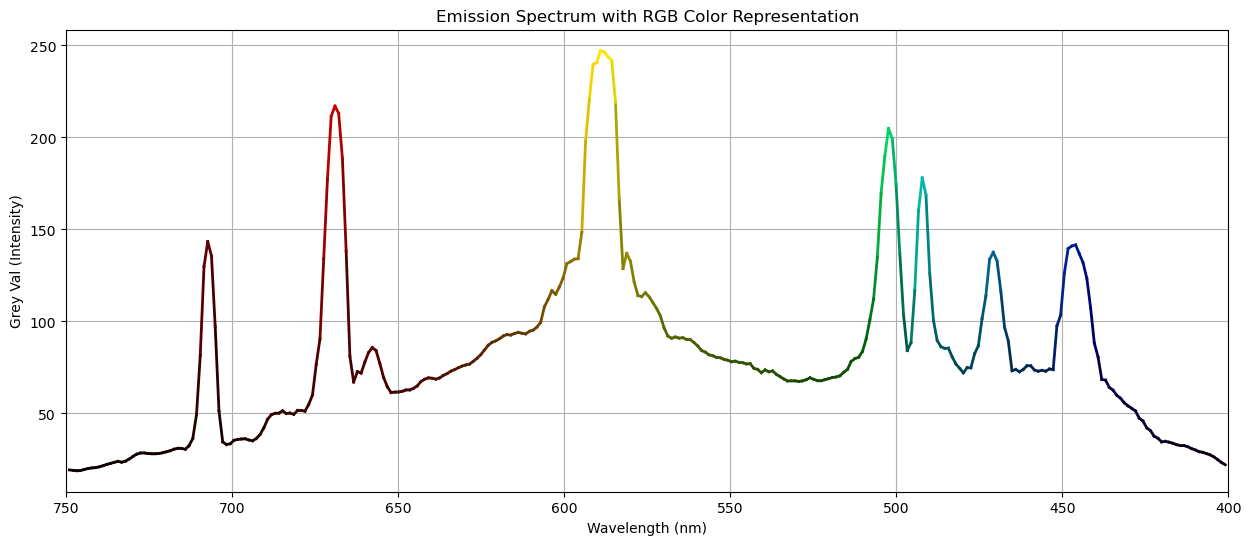

This plot displays the emission spectrum where each segment's color is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity).
The 'rgb' function maps wavelengths to corresponding colors in the visible spectrum, and the 'Normalized_Grey_Val' adjusts the perceived brightness of these colors.


In [26]:
# Normalize Grey Val for intensity scaling

# Avoid division by zero if all Grey Vals are the same
if grey_val_range == 0:
    df_filtered['Normalized_Grey_Val'] = 1.0
else:
    df_filtered['Normalized_Grey_Val'] = (df_filtered['Grey Val'] - min_grey_val) / grey_val_range

# Create the plot
plt.figure(figsize=(15, 6))

# Plot each segment with its corresponding RGB color and intensity
for i in range(len(df_filtered) - 1):
    wavelength_start = df_filtered.iloc[i]['nm']
    wavelength_end = df_filtered.iloc[i+1]['nm']

    # Use the normalized Grey Val of the first point in the segment for intensity
    grey_val_intensity_factor = df_filtered.iloc[i]['Normalized_Grey_Val']

    # Get base RGB color for the start wavelength
    base_rgb = rgb(wavelength_start)

    # Apply intensity to RGB. We can add a base brightness to ensure even low intensity peaks are visible.
    min_brightness = 0.1 # Minimum brightness for any point (0.0 to 1.0)
    # Scale the intensity factor to ensure it ranges from min_brightness to 1.0
    final_intensity_scale = min_brightness + (1 - min_brightness) * grey_val_intensity_factor

    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)

    plt.plot([wavelength_start, wavelength_end],
             [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
             color=colored_rgb,
             linewidth=2)

plt.title('Emission Spectrum with RGB Color Representation')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Grey Val (Intensity)')
plt.xlim(750, 400) # Keep x-axis reversed as per previous request
plt.grid(True)
plt.show()

print("This plot displays the emission spectrum where each segment's color is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity).")
print("The 'rgb' function maps wavelengths to corresponding colors in the visible spectrum, and the 'Normalized_Grey_Val' adjusts the perceived brightness of these colors.")

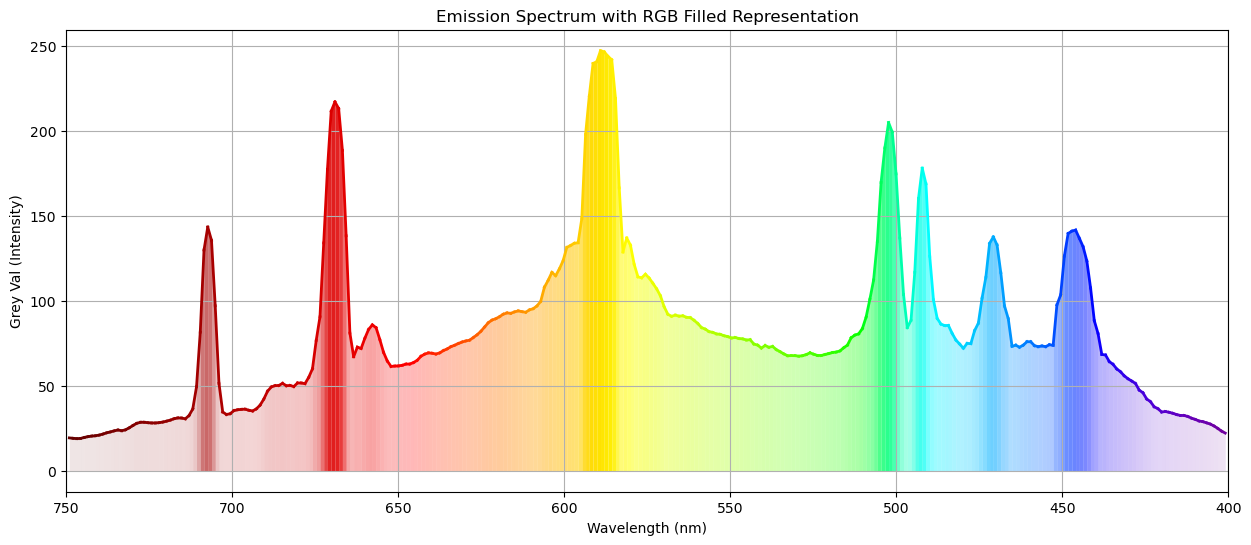

This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors.
The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions, similar to how emission spectra are often presented.


In [27]:
# Function to convert wavelength (nm) to RGB color
# Normalize Grey Val for intensity scaling
min_grey_val = df_filtered['Grey Val'].min()
max_grey_val = df_filtered['Grey Val'].max()
grey_val_range = max_grey_val - min_grey_val

if grey_val_range == 0:
    df_filtered['Normalized_Grey_Val'] = 1.0
else:
    df_filtered['Normalized_Grey_Val'] = (df_filtered['Grey Val'] - min_grey_val) / grey_val_range

# Create the plot
plt.figure(figsize=(15, 6))
ax = plt.gca() # Get current axes

# Iterate through each segment to apply specific color and alpha
for i in range(len(df_filtered) - 1):
    wavelength_start = df_filtered.iloc[i]['nm']
    wavelength_end = df_filtered.iloc[i+1]['nm']

    # Use the wavelength at the start of the segment for color mapping
    base_rgb = rgb(wavelength_start)

    # Use the normalized Grey Val of the first point in the segment for alpha (transparency)
    # Scale alpha to ensure low intensity regions are still visible but fainter
    alpha_factor = df_filtered.iloc[i]['Normalized_Grey_Val']
    min_alpha = 0.1 # Minimum transparency for visibility (0.0 to 1.0)
    # Scale alpha factor: from min_alpha at lowest normalized intensity to 1.0 at highest
    final_alpha = min_alpha + (1 - min_alpha) * alpha_factor

    # Fill the area under the curve for this segment
    plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']], # Top of the fill
                     color=base_rgb,
                     alpha=final_alpha,
                     linewidth=0) # No line for the fill edges

    # Plot the line on top for clarity, using the base color for the line itself
    plt.plot([wavelength_start, wavelength_end],
             [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
             color=base_rgb,
             linewidth=2) # Thicker line for better visibility on top of fill


plt.title('Emission Spectrum with RGB Filled Representation')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Grey Val (Intensity)')
plt.xlim(750, 400) # Keep x-axis reversed as per previous request
plt.grid(True)
plt.show()

print("This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors.")
print("The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions, similar to how emission spectra are often presented.")

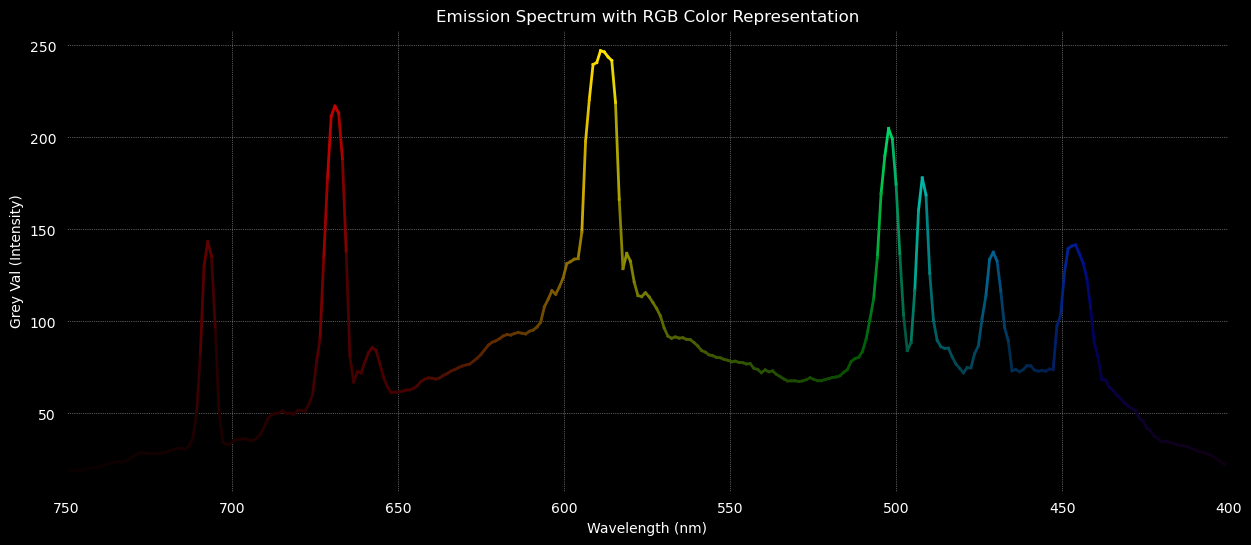

This plot displays the emission spectrum with a black background, using sharp, distinct lines.
The color of each line segment is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity), creating a visual representation similar to a traditional emission spectrum.


In [28]:
if grey_val_range == 0:
    df_filtered['Normalized_Grey_Val'] = 1.0
else:
    df_filtered['Normalized_Grey_Val'] = (df_filtered['Grey Val'] - min_grey_val) / grey_val_range

# Create the plot
plt.figure(figsize=(15, 6))
ax = plt.gca() # Get current axes

# Set background color to black
ax.set_facecolor('black')
plt.gcf().set_facecolor('black') # Set figure background color as well

# Plot each segment with its corresponding RGB color and intensity
for i in range(len(df_filtered) - 1):
    wavelength_start = df_filtered.iloc[i]['nm']
    wavelength_end = df_filtered.iloc[i+1]['nm']

    # Use the normalized Grey Val of the first point in the segment for intensity
    grey_val_intensity_factor = df_filtered.iloc[i]['Normalized_Grey_Val']

    # Get base RGB color for the start wavelength
    base_rgb = rgb(wavelength_start)

    # Apply intensity to RGB. We can add a base brightness to ensure even low intensity peaks are visible.
    min_brightness = 0.1 # Minimum brightness for any point (0.0 to 1.0)
    # Scale the intensity factor to ensure it ranges from min_brightness to 1.0
    final_intensity_scale = min_brightness + (1 - min_brightness) * grey_val_intensity_factor

    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)

    plt.plot([wavelength_start, wavelength_end],
             [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
             color=colored_rgb,
             linewidth=2) # Keep linewidth for sharp distinct lines

plt.title('Emission Spectrum with RGB Color Representation', color='white') # Set title color to white
plt.xlabel('Wavelength (nm)', color='white') # Set x-label color to white
plt.ylabel('Grey Val (Intensity)', color='white') # Set y-label color to white
plt.xticks(color='white') # Set x-tick labels color to white
plt.yticks(color='white') # Set y-tick labels color to white
plt.xlim(750, 400) # Keep x-axis reversed as per previous request
plt.grid(True, color='darkgrey', linestyle=':', linewidth=0.5) # Adjust grid color and style for black background
plt.show()

print("This plot displays the emission spectrum with a black background, using sharp, distinct lines.")
print("The color of each line segment is determined by its wavelength, and its brightness is modulated by its 'Grey Val' (intensity), creating a visual representation similar to a traditional emission spectrum.")

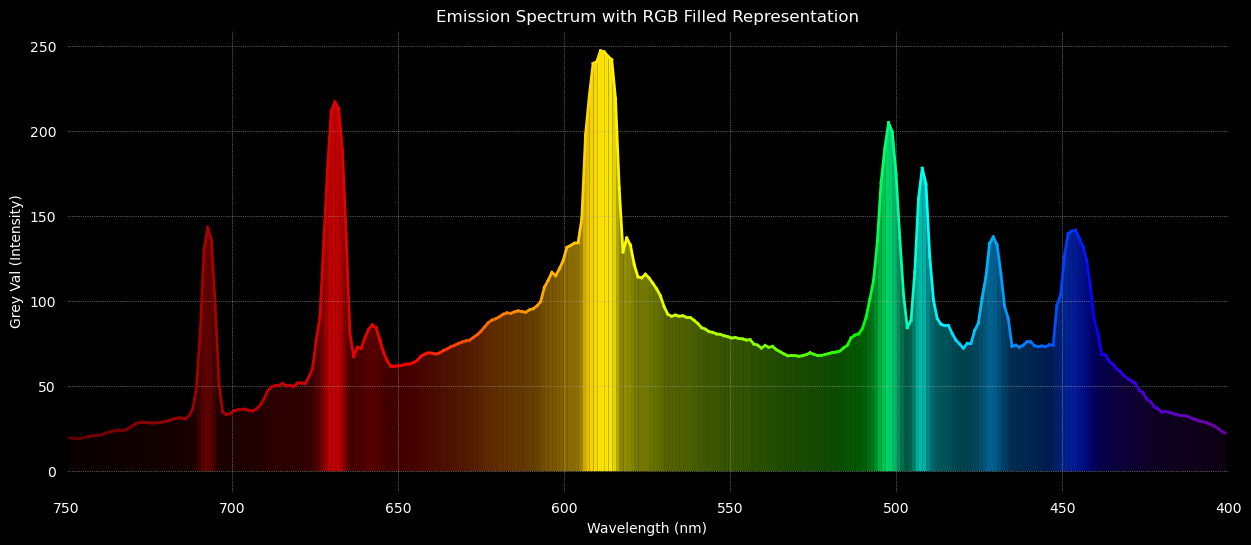

This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors, against a black background.
The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions.


In [29]:
if grey_val_range == 0:
    df_filtered['Normalized_Grey_Val'] = 1.0
else:
    df_filtered['Normalized_Grey_Val'] = (df_filtered['Grey Val'] - min_grey_val) / grey_val_range

# Create the plot
plt.figure(figsize=(15, 6))
ax = plt.gca() # Get current axes

# Set background color to black
ax.set_facecolor('black')
plt.gcf().set_facecolor('black') # Set figure background color as well

# Iterate through each segment to apply specific color and alpha
for i in range(len(df_filtered) - 1):
    wavelength_start = df_filtered.iloc[i]['nm']
    wavelength_end = df_filtered.iloc[i+1]['nm']

    # Use the wavelength at the start of the segment for color mapping
    base_rgb = rgb(wavelength_start)

    # Use the normalized Grey Val of the first point in the segment for alpha (transparency)
    # Scale alpha to ensure low intensity regions are still visible but fainter
    alpha_factor = df_filtered.iloc[i]['Normalized_Grey_Val']
    min_alpha = 0.1 # Minimum transparency for visibility (0.0 to 1.0)
    # Scale alpha factor: from min_alpha at lowest normalized intensity to 1.0 at highest
    final_alpha = min_alpha + (1 - min_alpha) * alpha_factor

    # Fill the area under the curve for this segment
    plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']], # Top of the fill
                     color=base_rgb,
                     alpha=final_alpha,
                     linewidth=0) # No line for the fill edges

    # Plot the line on top for clarity, using the base color for the line itself
    plt.plot([wavelength_start, wavelength_end],
             [df_filtered.iloc[i]['Grey Val'], df_filtered.iloc[i+1]['Grey Val']],
             color=base_rgb,
             linewidth=2) # Thicker line for better visibility on top of fill

plt.title('Emission Spectrum with RGB Filled Representation', color='white') # Set title color to white
plt.xlabel('Wavelength (nm)', color='white') # Set x-label color to white
plt.ylabel('Grey Val (Intensity)', color='white') # Set y-label color to white
plt.xticks(color='white') # Set x-tick labels color to white
plt.yticks(color='white') # Set y-tick labels color to white
plt.xlim(750, 400) # Keep x-axis reversed as per previous request
plt.grid(True, color='darkgrey', linestyle=':', linewidth=0.5) # Adjust grid color and style for black background
plt.show()

print("This plot now displays the emission spectrum with the area under the curve filled with wavelength-dependent colors, against a black background.")
print("The intensity of the emitted light (Grey Val) now directly influences the opacity (alpha) of the filled region, creating a more vivid 'glowing' effect for brighter emissions.")

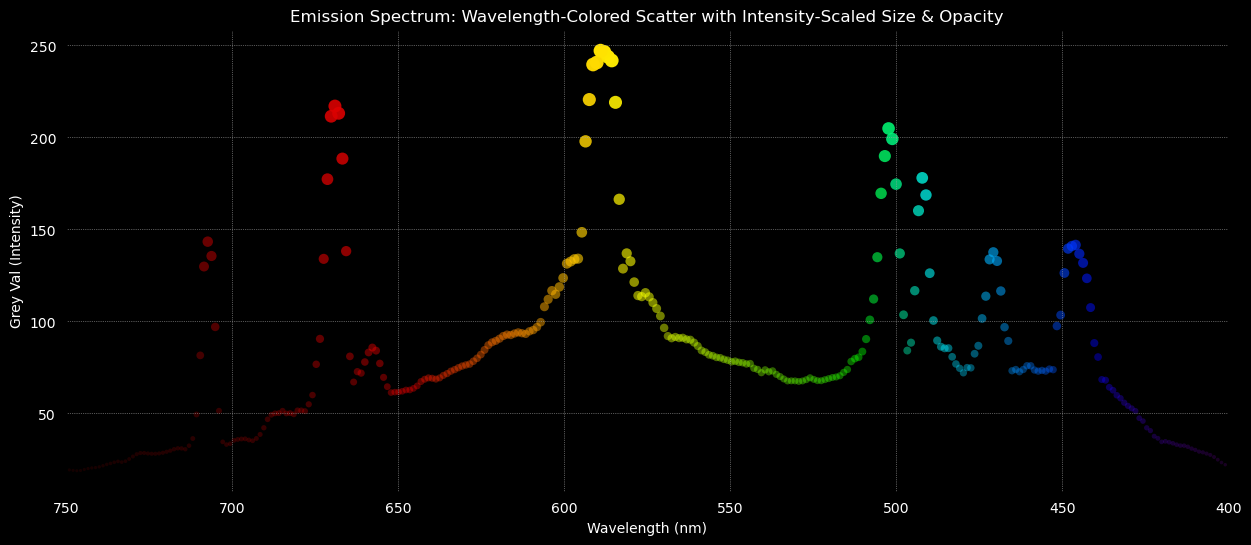

This visualization presents the emission spectrum as a scatter plot.
Each point is colored according to its wavelength, and its size and opacity (alpha) are scaled by its 'Grey Val' (intensity).
This creates a 'fuzzy' or 'sparkling' effect, distinct from continuous lines or filled areas, offering another perspective on the spectral data.


In [30]:
if grey_val_range == 0:
    df_filtered['Normalized_Grey_Val'] = 1.0
else:
    df_filtered['Normalized_Grey_Val'] = (df_filtered['Grey Val'] - min_grey_val) / grey_val_range

# Create the plot
plt.figure(figsize=(15, 6))
ax = plt.gca() # Get current axes

# Set background color to black
ax.set_facecolor('black')
plt.gcf().set_facecolor('black') # Set figure background color as well

# Set X-axis labels and color
plt.xlabel('Wavelength (nm)', color='white') # Set x-label color to white
plt.ylabel('Grey Val (Intensity)', color='white') # Set y-label color to white
plt.xticks(color='white') # Set x-tick labels color to white
plt.yticks(color='white') # Set y-tick labels color to white
plt.xlim(750, 400) # Keep x-axis reversed as per previous request
plt.grid(True, color='darkgrey', linestyle=':', linewidth=0.5) # Adjust grid color and style for black background

# Prepare colors, sizes, and alphas for the scatter plot
# Scale marker size: from a base size (e.g., 5) to a max size (e.g., 100) based on normalized intensity
base_marker_size = 5
max_marker_size_factor = 95 # max_size = base_marker_size + max_marker_size_factor
sizes = base_marker_size + (max_marker_size_factor * df_filtered['Normalized_Grey_Val'])

# Scale alpha (opacity)
min_alpha_scatter = 0.2 # Minimum transparency for low intensity points
alphas = min_alpha_scatter + (1 - min_alpha_scatter) * df_filtered['Normalized_Grey_Val']

# Create RGBA tuples for each point
rgba_colors = []
for i in range(len(df_filtered)):
    wavelength = df_filtered.iloc[i]['nm']
    r, g, b = rgb(wavelength)
    a = alphas.iloc[i] # get the alpha for this point
    rgba_colors.append((r, g, b, a))

plt.scatter(
    x=df_filtered['nm'],
    y=df_filtered['Grey Val'],
    c=rgba_colors, # Use RGBA colors
    s=sizes,
    edgecolors='none', # No edge colors for the markers
    label='Emission Data'
)

plt.title('Emission Spectrum: Wavelength-Colored Scatter with Intensity-Scaled Size & Opacity', color='white')
plt.show()

print("This visualization presents the emission spectrum as a scatter plot.")
print("Each point is colored according to its wavelength, and its size and opacity (alpha) are scaled by its 'Grey Val' (intensity).")
print("This creates a 'fuzzy' or 'sparkling' effect, distinct from continuous lines or filled areas, offering another perspective on the spectral data.")

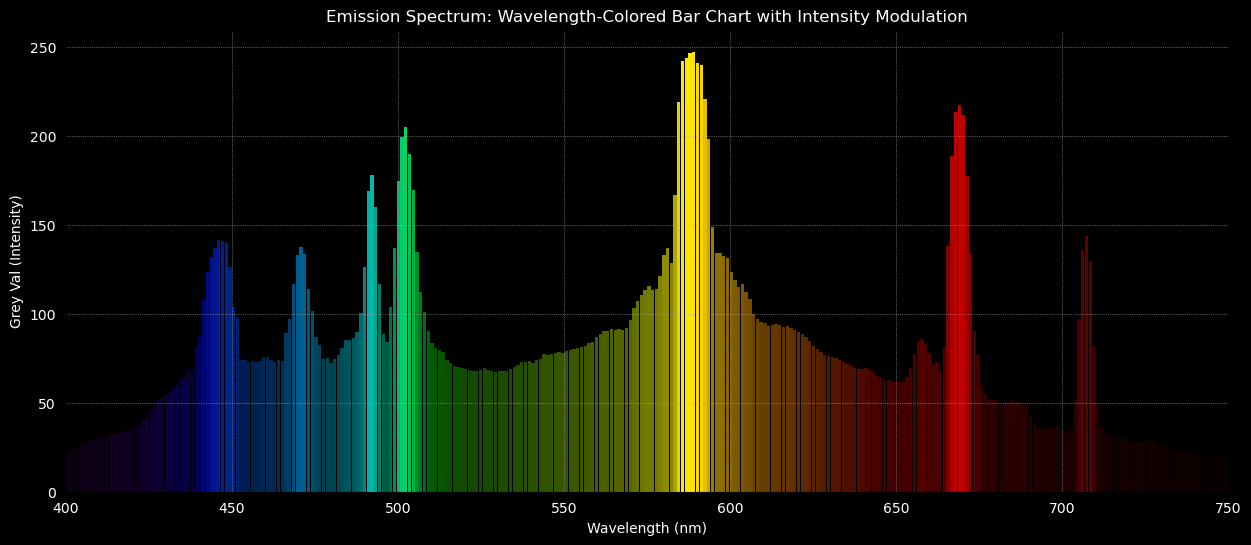

This visualization presents the emission spectrum as a bar chart.
Each bar's color is determined by its wavelength, and its brightness is scaled by its 'Grey Val' (intensity).
The bars represent discrete wavelength intervals, offering a block-like view of the spectrum.


In [ ]:
if grey_val_range == 0:
    df_filtered['Normalized_Grey_Val'] = 1.0
else:
    df_filtered['Normalized_Grey_Val'] = (df_filtered['Grey Val'] - min_grey_val) / grey_val_range

# Create the plot
plt.figure(figsize=(15, 6))
ax = plt.gca() # Get current axes

# Set background color to black
ax.set_facecolor('black')
plt.gcf().set_facecolor('black') # Set figure background color as well

# Set X-axis labels and color
plt.xlabel('Wavelength (nm)', color='white') # Set x-label color to white
plt.ylabel('Grey Val (Intensity)', color='white') # Set y-label color to white
plt.xticks(color='white') # Set x-tick labels color to white
plt.yticks(color='white') # Set y-tick labels color to white
plt.xlim(400, 750) # Set x-axis order from 400 to 750
plt.grid(True, color='darkgrey', linestyle=':', linewidth=0.5) # Adjust grid color and style for black background

# Prepare colors for each bar
bar_colors = []
min_brightness = 0.1 # Minimum brightness for any bar
for index, row in df_filtered.iterrows():
    wavelength = row['nm']
    normalized_intensity = row['Normalized_Grey_Val']

    base_rgb = rgb(wavelength)

    # Scale the intensity factor for brightness
    final_intensity_scale = min_brightness + (1 - min_brightness) * normalized_intensity

    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)
    bar_colors.append(colored_rgb)

# Calculate bar widths. Assuming approximately even spacing for visualization.
# A fixed width might be simpler if exact binning is not required.
# Using a fixed width of 1nm for each bar, centered at the 'nm' value.
bar_width = 1

plt.bar(
    x=df_filtered['nm'],
    height=df_filtered['Grey Val'],
    width=bar_width,
    color=bar_colors,
    edgecolor='none' # No edge color for bars
)

plt.title('Emission Spectrum: Wavelength-Colored Bar Chart with Intensity Modulation', color='white')
plt.show()

print("This visualization presents the emission spectrum as a bar chart.")
print("Each bar's color is determined by its wavelength, and its brightness is scaled by its 'Grey Val' (intensity).")
print("The bars represent discrete wavelength intervals, offering a block-like view of the spectrum.")

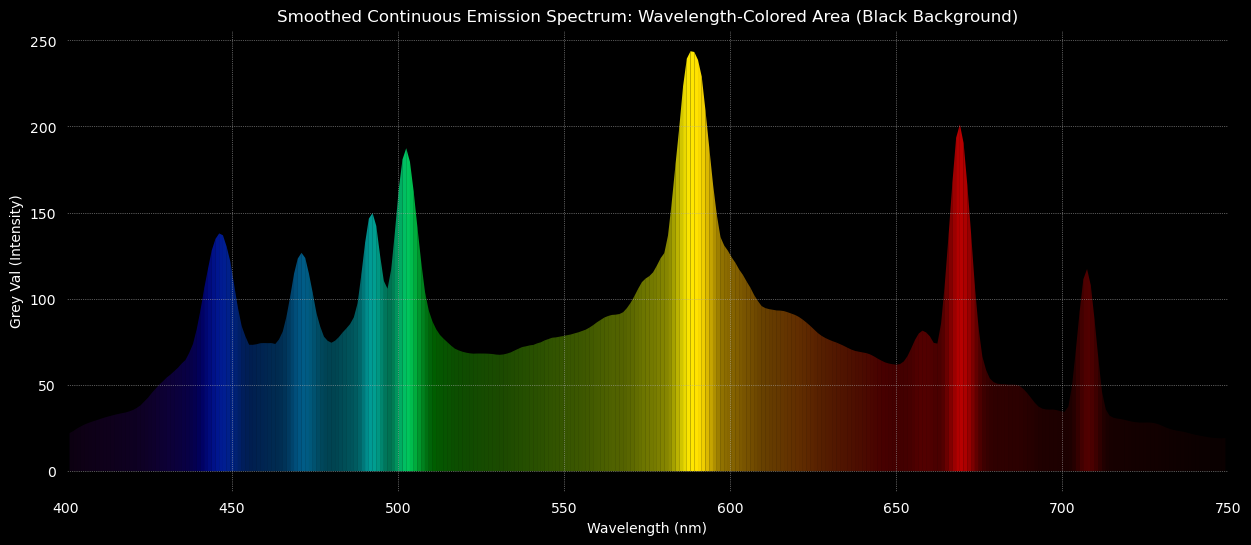

This visualization presents the emission spectrum as a smoothed, continuous area plot against a black background.
A rolling mean has been applied to the 'Grey Val' data to create a smoother curve.
Each segment's color is determined by its wavelength, and its opacity (alpha) is scaled by its intensity, providing a glowing representation.


In [32]:
# Apply a rolling mean for smoothing
smoothing_window = 5 # Increased this value to control the degree of smoothing
df_filtered['Smoothed_Grey_Val'] = df_filtered['Grey Val'].rolling(window=smoothing_window, center=True).mean().fillna(df_filtered['Grey Val'])

# Normalize Smoothed_Grey_Val for intensity scaling
min_grey_val = df_filtered['Smoothed_Grey_Val'].min()
max_grey_val = df_filtered['Smoothed_Grey_Val'].max()
grey_val_range = max_grey_val - min_grey_val

if grey_val_range == 0:
    df_filtered['Normalized_Grey_Val'] = 1.0
else:
    df_filtered['Normalized_Grey_Val'] = (df_filtered['Smoothed_Grey_Val'] - min_grey_val) / grey_val_range

# Create the plot
plt.figure(figsize=(15, 6))
ax = plt.gca() # Get current axes

# Set background color to BLACK
ax.set_facecolor('black')
plt.gcf().set_facecolor('black') # Set figure background color as well

# Set X-axis labels and color
plt.xlabel('Wavelength (nm)', color='white') # Set x-label color to white
plt.ylabel('Grey Val (Intensity)', color='white') # Set y-label color to white
plt.xticks(color='white') # Set x-tick labels color to white
plt.yticks(color='white') # Set y-tick labels color to white
plt.xlim(400, 750) # Set x-axis order from 400 to 750
plt.grid(True, color='darkgrey', linestyle=':', linewidth=0.5) # Adjust grid color and style for black background

# Iterate through each segment to apply specific color and alpha
for i in range(len(df_filtered) - 1):
    wavelength_start = df_filtered.iloc[i]['nm']
    wavelength_end = df_filtered.iloc[i+1]['nm']

    # Use the wavelength at the start of the segment for color mapping
    base_rgb = rgb(wavelength_start)

    # Use the normalized Grey Val of the first point in the segment for alpha (transparency)
    # Scale alpha to ensure low intensity regions are still visible but fainter
    alpha_factor = df_filtered.iloc[i]['Normalized_Grey_Val']
    min_alpha = 0.1 # Minimum transparency for visibility (0.0 to 1.0)
    # Scale alpha factor: from min_alpha at lowest normalized intensity to 1.0 at highest
    final_alpha = min_alpha + (1 - min_alpha) * alpha_factor

    # Fill the area under the curve for this segment using 'Smoothed_Grey_Val'
    plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [df_filtered.iloc[i]['Smoothed_Grey_Val'], df_filtered.iloc[i+1]['Smoothed_Grey_Val']], # Top of the fill
                     color=base_rgb,
                     alpha=final_alpha,
                     linewidth=0) # No line for the fill edges

plt.title('Smoothed Continuous Emission Spectrum: Wavelength-Colored Area (Black Background)', color='white')
plt.show()

print("This visualization presents the emission spectrum as a smoothed, continuous area plot against a black background.")
print("A rolling mean has been applied to the 'Grey Val' data to create a smoother curve.")
print("Each segment's color is determined by its wavelength, and its opacity (alpha) is scaled by its intensity, providing a glowing representation.")

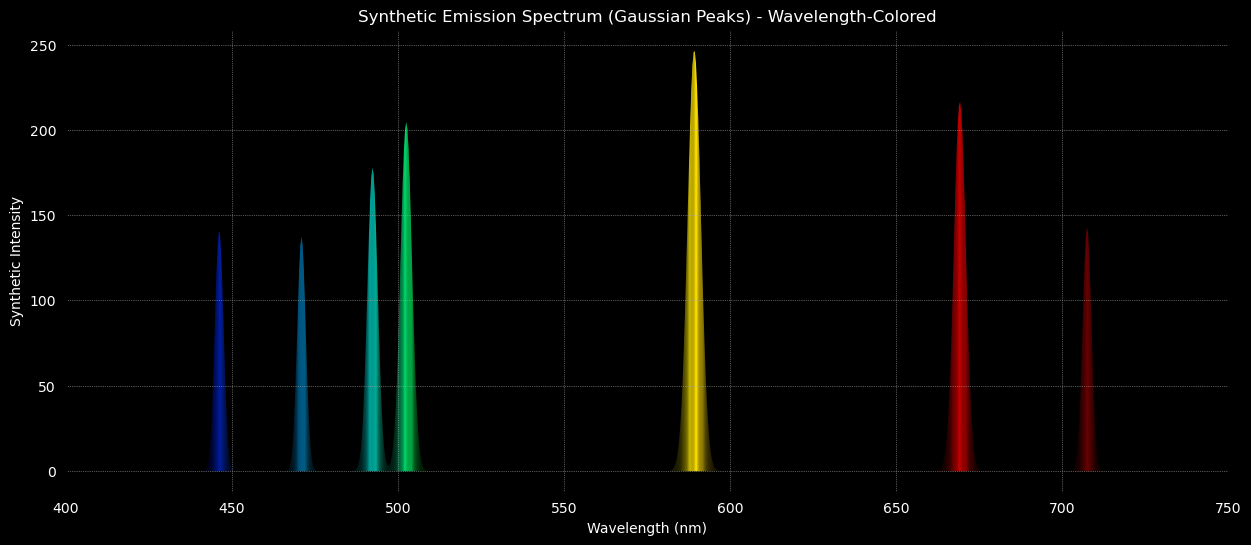

This visualization constructs a synthetic emission spectrum by representing each detected peak as a Gaussian curve.
The amplitude of each Gaussian corresponds to the peak's intensity, and its width is also scaled by intensity, simulating line broadening.
The resulting smooth, continuous curve is colored by wavelength, with opacity adjusted by the synthetic intensity, creating a soft, glowing effect.


In [33]:
# --- Synthetic Spectrum (Gaussian Peaks) Visualization --- #

# Parameters for Gaussian synthesis
peak_prominence_threshold = 0.12 # Same as previous peak detection
gamma_factor = 0.8 # For rgb function

# Prepare data (filter and sort)
df_plot_data = df_filtered[(df_filtered['nm'] >= 400) & (df_filtered['nm'] <= 750)].copy()
df_plot_data = df_plot_data.sort_values(by='nm').reset_index(drop=True)

# Normalize 'Grey Val' for peak amplitude
min_intensity = df_plot_data['Grey Val'].min()
max_intensity = df_plot_data['Grey Val'].max()
intensity_range = max_intensity - min_intensity

if intensity_range == 0:
    df_plot_data['Normalized_Intensity'] = 1.0
else:
    df_plot_data['Normalized_Intensity'] = (df_plot_data['Grey Val'] - min_intensity) / intensity_range

# Detect peaks
dynamic_prominence = peak_prominence_threshold * intensity_range
peaks_indices, properties = find_peaks(df_plot_data['Grey Val'], prominence=dynamic_prominence)

# Create a new, denser wavelength array for plotting the synthetic spectrum
x_synthetic = np.linspace(400, 750, 1000) # 1000 points for a smooth synthetic curve
y_synthetic = np.zeros_like(x_synthetic)

# Parameters for Gaussian widths (standard deviation)
base_sigma_nm = 0.5 # Base width of the Gaussian (for low intensity peaks)
max_sigma_multiplier = 4.0 # How much wider the highest intensity peaks can be

# Generate a sum of Gaussians for the synthetic spectrum
for i, peak_idx in enumerate(peaks_indices):
    peak_nm = df_plot_data.iloc[peak_idx]['nm']
    peak_amplitude = df_plot_data.iloc[peak_idx]['Grey Val']
    normalized_amplitude = df_plot_data.iloc[peak_idx]['Normalized_Intensity']

    # Scale sigma based on normalized intensity (higher intensity = broader peak)
    sigma = base_sigma_nm + (max_sigma_multiplier - 1) * base_sigma_nm * normalized_amplitude

    # Create a Gaussian curve for this peak
    gaussian_curve = peak_amplitude * np.exp(-((x_synthetic - peak_nm)**2) / (2 * sigma**2))
    y_synthetic += gaussian_curve # Add to the total synthetic spectrum

# Normalize the synthetic spectrum intensities for coloring (if desired, not strictly necessary for area plot)
min_y_synthetic = y_synthetic.min()
max_y_synthetic = y_synthetic.max()
if (max_y_synthetic - min_y_synthetic) == 0:
    normalized_y_synthetic = np.ones_like(y_synthetic)
else:
    normalized_y_synthetic = (y_synthetic - min_y_synthetic) / (max_y_synthetic - min_y_synthetic)

# Create the plot
plt.figure(figsize=(15, 6))
ax = plt.gca()

ax.set_facecolor('black')
plt.gcf().set_facecolor('black')

plt.xlabel('Wavelength (nm)', color='white')
plt.ylabel('Synthetic Intensity', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.xlim(400, 750)
plt.grid(True, color='darkgrey', linestyle=':', linewidth=0.5)

# Iterate through each segment of the synthetic spectrum to apply color and alpha
for i in range(len(x_synthetic) - 1):
    wavelength_start = x_synthetic[i]
    wavelength_end = x_synthetic[i+1]

    base_rgb = rgb(wavelength_start, gamma=gamma_factor)

    # Scale alpha by normalized synthetic intensity
    # A base alpha ensures even low intensity regions are visible
    min_alpha = 0.1
    final_alpha = min_alpha + (1 - min_alpha) * normalized_y_synthetic[i]

    plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0],
                     [y_synthetic[i], y_synthetic[i+1]],
                     color=base_rgb,
                     alpha=final_alpha,
                     linewidth=0)

plt.title('Synthetic Emission Spectrum (Gaussian Peaks) - Wavelength-Colored', color='white')
plt.show()

print("This visualization constructs a synthetic emission spectrum by representing each detected peak as a Gaussian curve.")
print("The amplitude of each Gaussian corresponds to the peak's intensity, and its width is also scaled by intensity, simulating line broadening.")
print("The resulting smooth, continuous curve is colored by wavelength, with opacity adjusted by the synthetic intensity, creating a soft, glowing effect.")

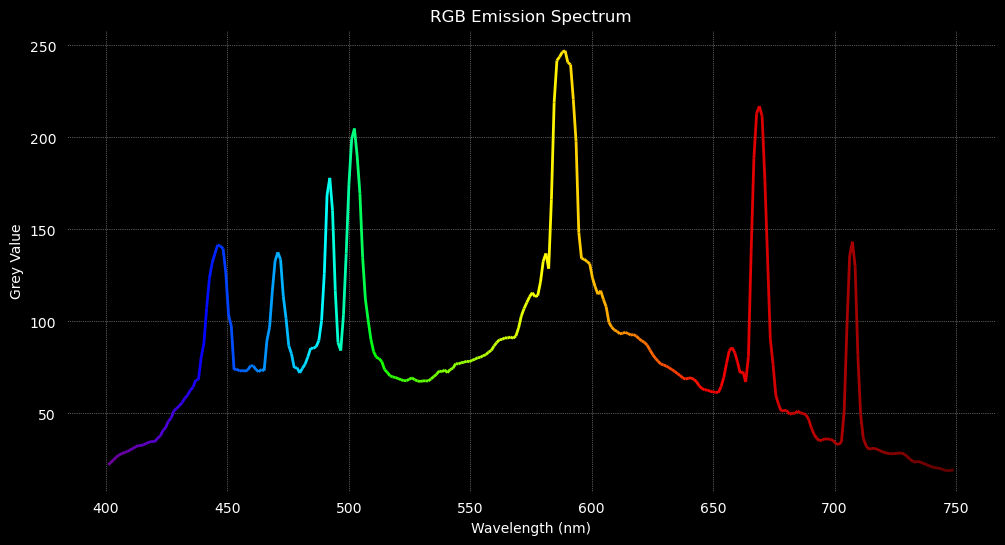

In [ ]:
def rgb(wavelength, gamma=0.8):
    """
    Converts a wavelength (nm) to an RGB color.
    Based on code by Dan Bruton (bruton@tamu.edu)
    http://www.physics.sfasu.edu/astro/color/spectra.html
    """
    wavelength = float(wavelength)
    if wavelength >= 380 and wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif wavelength >= 440 and wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = (1.0) ** gamma
    elif wavelength >= 490 and wavelength <= 510:
        R = 0.0
        G = (1.0) ** gamma
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif wavelength >= 510 and wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = (1.0) ** gamma
        B = 0.0
    elif wavelength >= 580 and wavelength <= 645:
        R = (1.0) ** gamma
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif wavelength >= 645 and wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    return (R, G, B)

# Apply the function to the 'nm' column to get RGB colors for each data point
colors = [rgb(nm) for nm in df_filtered['nm']]

# Prepare data for LineCollection
x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

# Create segments for LineCollection
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create a LineCollection with the calculated colors
lc = LineCollection(segments, colors=colors, linewidth=2)

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.add_collection(lc)
ax.autoscale()
plt.xticks(color='white') # Set x-tick labels color to white
plt.yticks(color='white') # Set y-tick labels color to white
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_facecolor('black')
plt.gcf().set_facecolor('black')
ax.set_ylabel('Grey Value', color='white')
ax.set_title('RGB Emission Spectrum', color='white')
ax.grid(True, color='darkgrey', linestyle=':', linewidth=0.5)
plt.show()

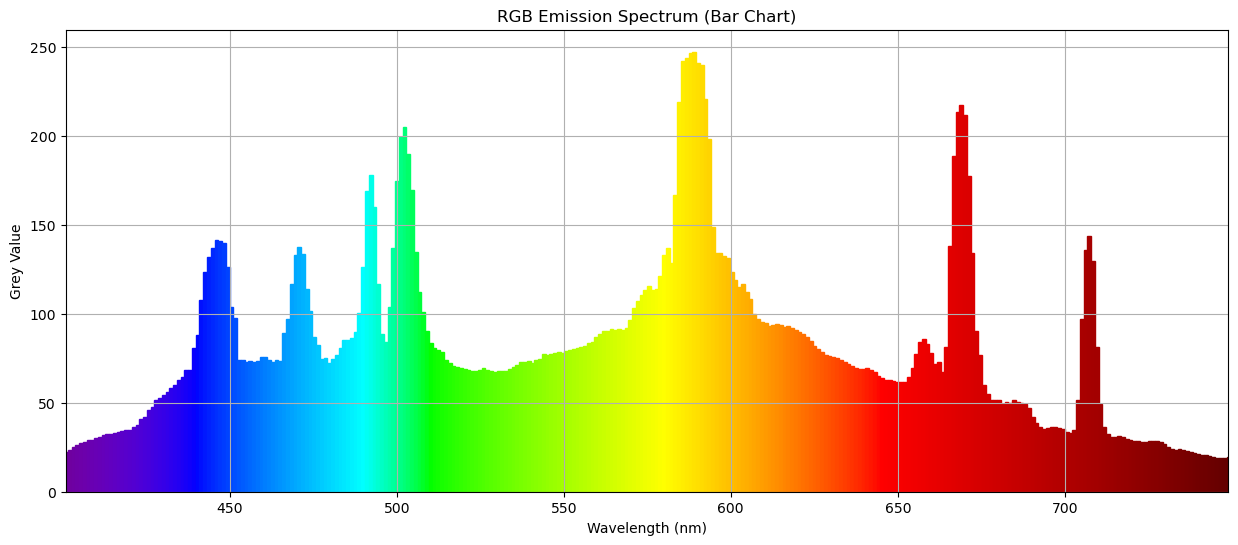

In [35]:
# Assuming df_filtered and colors (from rgb) are available from previous cells

x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

# Create a bar chart with colors corresponding to the wavelength
plt.figure(figsize=(15, 6))
# Use a small width for the bars to make it look continuous
bar_width = np.diff(x).mean() if len(x) > 1 else 1

for i in range(len(x)):
    plt.bar(x[i], y[i], color=colors[i], width=bar_width, edgecolor=colors[i])

plt.xlabel('Wavelength (nm)')
plt.ylabel('Grey Value')
plt.title('RGB Emission Spectrum (Bar Chart)')
plt.grid(True)
plt.xlim(x.min(), x.max()) # Ensure x-axis limits match data range
plt.show()

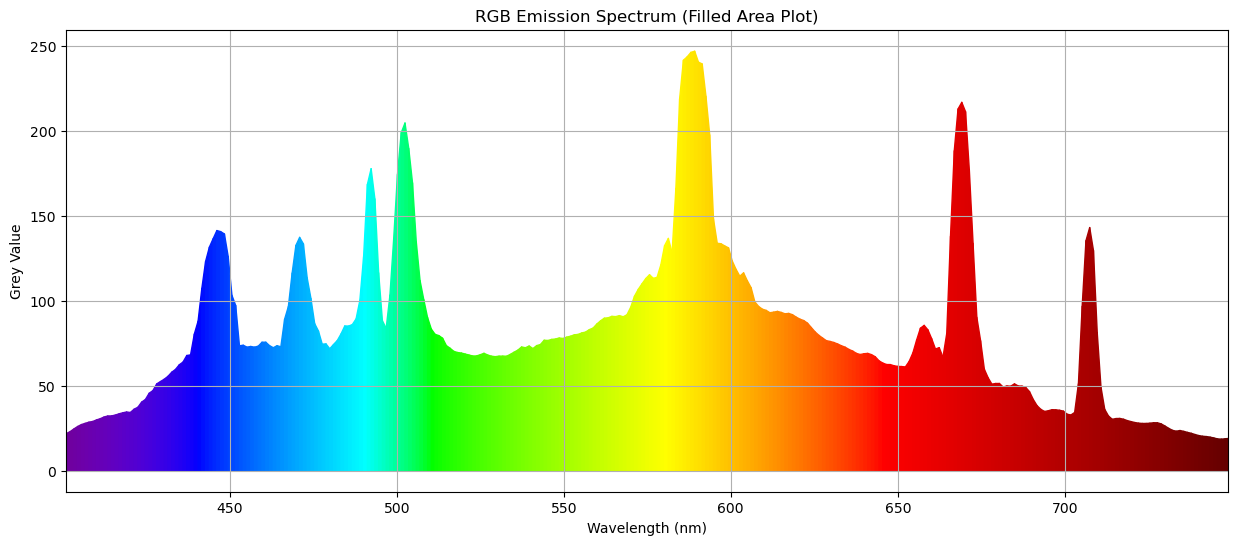

In [36]:
# Assuming df_filtered and colors (from rgb) are available from previous cells

x = df_filtered['nm'].values
y = df_filtered['Grey Val'].values

# Create a colormap from the generated RGB colors
# Need to normalize the colors to be from 0 to 1 for the colormap to work correctly with x_normalized
normalized_colors = [(c[0], c[1], c[2]) for c in colors]

# Create a custom colormap from the list of RGB colors
cmap = LinearSegmentedColormap.from_list("spectrum_cmap", normalized_colors, N=len(x))

# Plotting
fig, ax = plt.subplots(figsize=(15, 6))

# Create a normalized version of x for the colormap mapping
x_normalized = (x - x.min()) / (x.max() - x.min())

# Fill the area under the curve with the custom colormap
for i in range(len(x) - 1):
    ax.fill_between(x[i:i+2], y[i:i+2], color=cmap(x_normalized[i]))

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Grey Value')
ax.set_title('RGB Emission Spectrum (Filled Area Plot)')
ax.grid(True)
ax.set_xlim(x.min(), x.max())
plt.show()

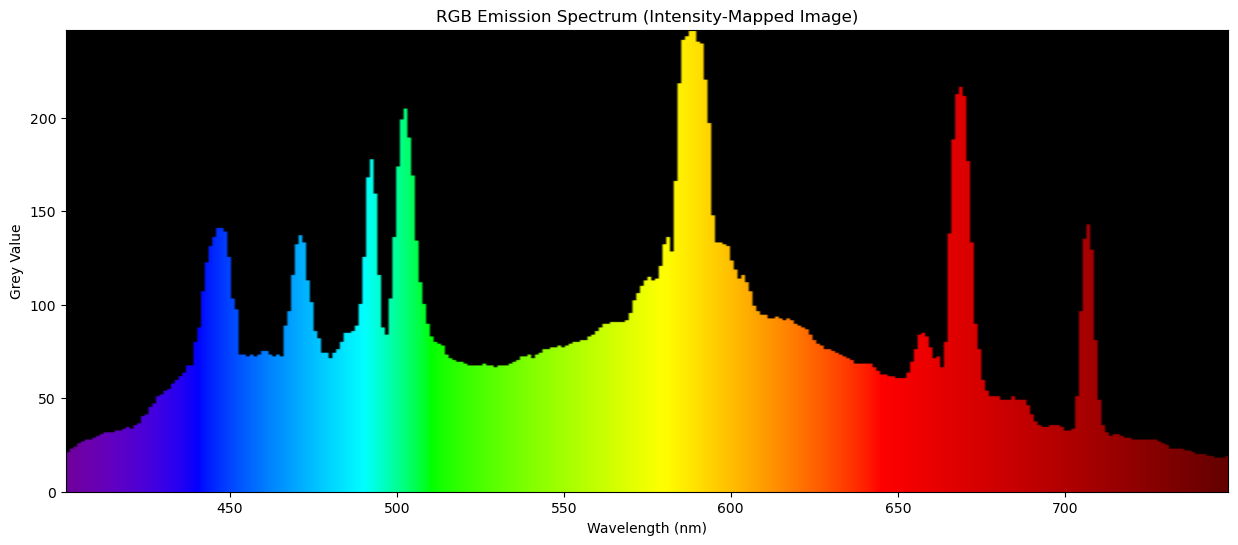

In [37]:
# Assuming df_filtered and colors list (from rgb) are available

x = df_filtered['nm'].values  # Wavelengths
y = df_filtered['Grey Val'].values # Grey Values

# Create a 2D array for the image data
# Max Grey Val will determine the effective height of the colored area
max_grey_val = y.max()

# Let's create an image with a fixed vertical resolution (e.g., 256 pixels for intensity levels)
# This helps in visualizing the 'Grey Val' as height in an image format
img_height = 256 # Number of vertical pixels for intensity representation
img_width = len(x) # Number of horizontal pixels (wavelengths)
spectrum_image = np.zeros((img_height, img_width, 3)) # RGB image

for i in range(img_width):
    # Get the spectral color for the current wavelength (already normalized 0-1)
    spectral_color = colors[i] 
    
    # Determine how many vertical pixels should be colored based on Grey Val
    # Scale Grey Val to the image height
    scaled_grey_val_pixels = int((y[i] / max_grey_val) * img_height)
    
    # Fill the column up to the scaled_grey_val_pixels with the spectral color
    # The 'origin='lower' in imshow means (0,0) is bottom-left, so we fill from bottom up.
    for j in range(scaled_grey_val_pixels):
        spectrum_image[j, i, 0] = spectral_color[0]
        spectrum_image[j, i, 1] = spectral_color[1]
        spectrum_image[j, i, 2] = spectral_color[2]

# Plotting the generated image
fig, ax = plt.subplots(figsize=(15, 6))

# Use imshow to display the spectrum image
# 'origin="lower"' ensures that y=0 is at the bottom of the plot
# 'extent' parameter labels the axes correctly based on data range
ax.imshow(spectrum_image, aspect='auto', origin='lower',
          extent=[x.min(), x.max(), 0, max_grey_val])

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Grey Value')
ax.set_title('RGB Emission Spectrum (Intensity-Mapped Image)')
ax.grid(False) # Turn off grid for a cleaner image plot
plt.show()

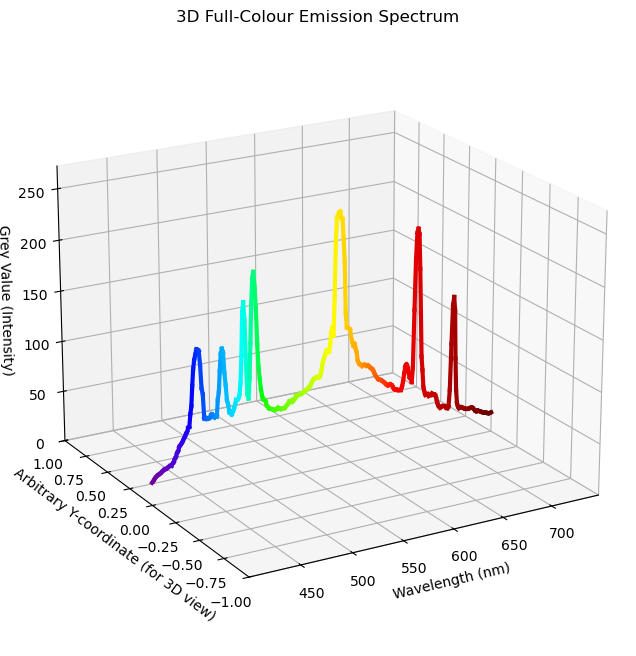

In [38]:
# Assuming df_filtered and rgb are available from previous cells.

x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# Create segments for the 3D line collection
# Each segment is defined by two points: (x1, y1, z1) and (x2, y2, z2)
# For a simple 3D line, we can keep the y-coordinate constant or slightly vary it.
# Let's keep y constant for a single plane visualization initially.
y_coords = np.full_like(x_wavelengths, 0) # Constant y-coordinate for simplicity

# Prepare data for Line3DCollection
points = np.array([x_wavelengths, y_coords, z_intensity]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Create a Line3DCollection with the calculated colors
# We need to ensure colors match segments (N-1 colors for N points)
line_collection = LineCollection(segments[:, :, :2], colors=spectral_colors[:-1], linewidth=3) # Use xy for LineCollection

# Plotting the 3D line with colors
# LineCollection in 3D is a bit tricky, it often expects 2D data for coloring, 
# and we need to explicitly plot the z-component or use plot() for 3D lines.
# Let's use ax.plot for each segment for direct color mapping in 3D, 
# as Line3DCollection can be less intuitive with coloring.

for i in range(len(x_wavelengths) - 1):
    ax.plot(x_wavelengths[i:i+2], y_coords[i:i+2], z_intensity[i:i+2],
            color=spectral_colors[i], linewidth=3)

# Set labels and title
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Arbitrary Y-coordinate (for 3D view)') # Can be made meaningful if multiple lines
ax.set_zlabel('Grey Value (Intensity)')
ax.set_title('3D Full-Colour Emission Spectrum')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
ax.set_ylim(-1, 1) # Small range for arbitrary Y
ax.set_zlim(0, z_intensity.max() * 1.1) # Some padding for intensity

# Adjust view angle for better perspective
ax.view_init(elev=20, azim=-120) # Elevation and Azimuth angle

plt.show()

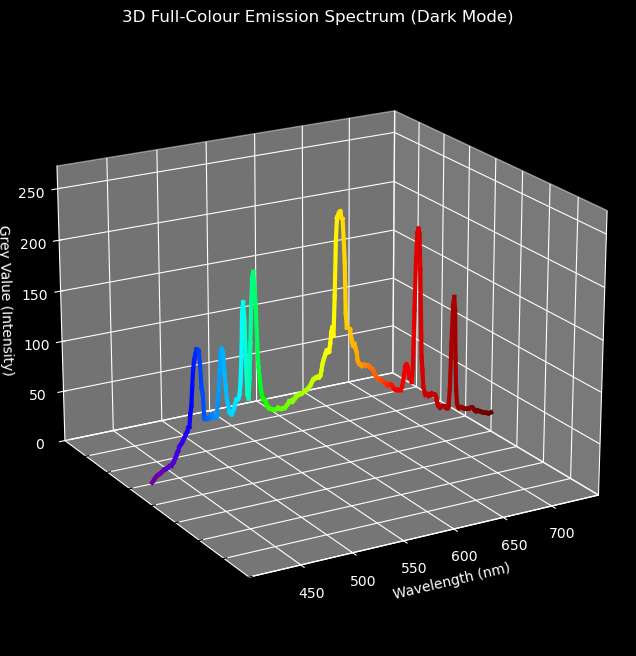

In [39]:
# Apply dark background style
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.

x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

y_coords = np.full_like(x_wavelengths, 0) # Constant y-coordinate for simplicity

for i in range(len(x_wavelengths) - 1):
    ax.plot(x_wavelengths[i:i+2], y_coords[i:i+2], z_intensity[i:i+2],
            color=spectral_colors[i], linewidth=3)

# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Arbitrary Y-coordinate (for 3D view)', color='black')
ax.set_zlabel('Grey Value (Intensity)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='black')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
ax.set_ylim(-1, 1) # Small range for arbitrary Y
ax.set_zlim(0, z_intensity.max() * 1.1) # Some padding for intensity

# Adjust view angle for better perspective
ax.view_init(elev=20, azim=-120) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


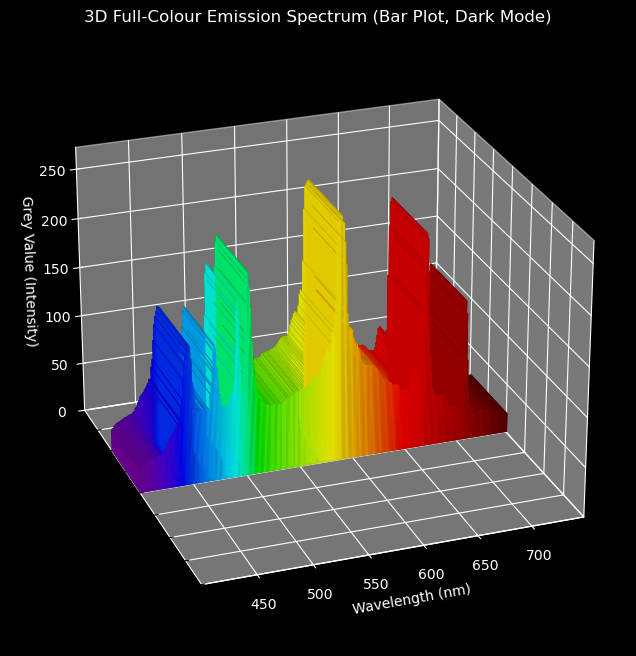

In [40]:
# Apply dark background style
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.

x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# For bar3d, we need x, y, z coordinates for the base, and dx, dy, dz for dimensions.
# We'll make each bar a thin slice along the x-axis (wavelength).
# The y-coordinate will be constant (e.g., 0) to keep it in a single plane for this view.

dx = np.diff(x_wavelengths) # Width of each bar along x-axis
dx = np.append(dx, dx[-1]) # Assume last bar has same width as previous

dy = 0.5 # A fixed depth for the bars along y-axis
dy_arr = np.full_like(x_wavelengths, dy)

dz = z_intensity # Height of each bar along z-axis

xpos = x_wavelengths # x-position of the base of each bar
ypos = np.full_like(x_wavelengths, 0) # y-position of the base of each bar (constant)
zpos = np.zeros_like(z_intensity) # z-position of the base of each bar (ground level)

# Convert RGB tuples to a format usable by bar3d (list of RGBA or RGB)
# Alpha can be adjusted if needed, but for solid bars, 1.0 is fine.
facecolors = np.array(spectral_colors)

# Plotting the 3D bars
ax.bar3d(xpos, ypos, zpos, dx, dy_arr, dz, color=facecolors, shade=True)

# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Arbitrary Depth', color='black') # Acknowledge the arbitrary Y-axis
ax.set_zlabel('Grey Value (Intensity)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Bar Plot, Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='black')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
ax.set_ylim(-1, 1) # Small range around 0 for arbitrary depth
ax.set_zlim(0, z_intensity.max() * 1.1) # Some padding for intensity

# Adjust view angle for better perspective
ax.view_init(elev=25, azim=-110) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


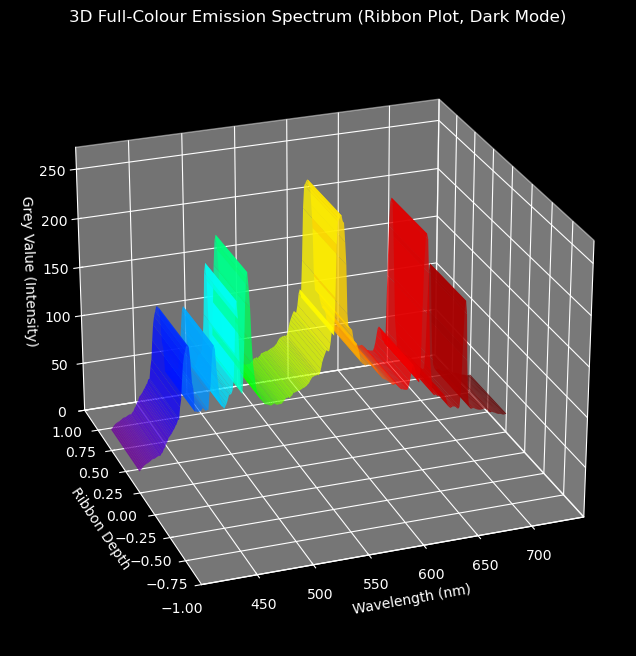

In [41]:
# Apply dark background style
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.

x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# Define a small 'depth' for the ribbon
ribbon_depth = 0.5

polygons = []
for i in range(len(x_wavelengths) - 1):
    x1, x2 = x_wavelengths[i], x_wavelengths[i+1]
    z1, z2 = z_intensity[i], z_intensity[i+1]
    
    # Define the four corners of each rectangle (quad)
    # Point 1: (x1, 0, z1)
    # Point 2: (x2, 0, z2)
    # Point 3: (x2, ribbon_depth, z2)
    # Point 4: (x1, ribbon_depth, z1)
    # This creates a quad that extends from y=0 to y=ribbon_depth

    poly = [
        (x1, 0, z1),
        (x2, 0, z2),
        (x2, ribbon_depth, z2),
        (x1, ribbon_depth, z1)
    ]
    polygons.append(poly)

# Create a Poly3DCollection to draw the ribbon segments
# We use spectral_colors[:-1] because there are N-1 segments for N data points
ax.add_collection3d(Poly3DCollection(polygons, facecolors=spectral_colors[:-1], edgecolors='none', alpha=0.8))

# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Ribbon Depth', color='white')
ax.set_zlabel('Grey Value (Intensity)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Ribbon Plot, Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
ax.set_ylim(-1, ribbon_depth + 0.5) # Adjust y-lim to see the ribbon
ax.set_zlim(0, z_intensity.max() * 1.1) # Some padding for intensity

# Adjust view angle for better perspective
ax.view_init(elev=25, azim=-110) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


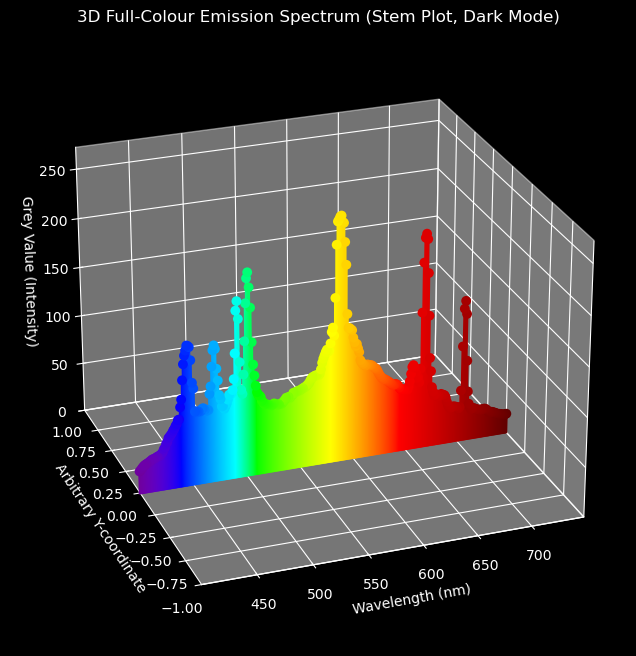

In [42]:
# Apply dark background style
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.

x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# For a stem plot, we typically plot lines from (x, y, 0) to (x, y, z_intensity)
# Let's keep the y-coordinate constant for simplicity, making it a 2D projection in 3D space.
y_coords = np.full_like(x_wavelengths, 0)

# Plot each stem individually to apply spectral colors
for i in range(len(x_wavelengths)):
    ax.plot([x_wavelengths[i], x_wavelengths[i]], # x-coordinates for stem
            [y_coords[i], y_coords[i]],         # y-coordinates for stem
            [0, z_intensity[i]],               # z-coordinates for stem (from 0 to intensity)
            color=spectral_colors[i], linewidth=2)
    
    # Optionally, add a marker at the top of each stem (the 'lollipop' part)
    ax.scatter(x_wavelengths[i], y_coords[i], z_intensity[i],
               color=spectral_colors[i], s=50, edgecolors='none')


# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Arbitrary Y-coordinate', color='white')
ax.set_zlabel('Grey Value (Intensity)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Stem Plot, Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
ax.set_ylim(-1, 1) # Small range for arbitrary Y
ax.set_zlim(0, z_intensity.max() * 1.1) # Some padding for intensity

# Adjust view angle for better perspective
ax.view_init(elev=25, azim=-110) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


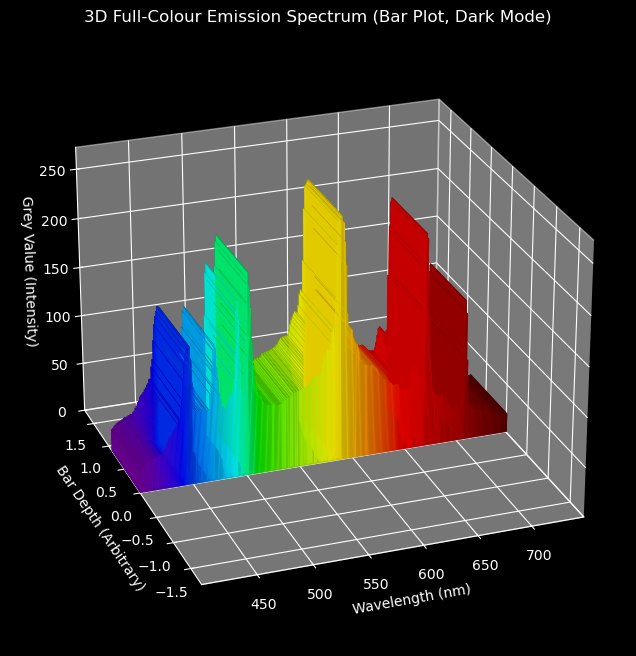

In [43]:
# Apply dark background style
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.

x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# For a 3D bar plot, we need positions (x, y, z) and dimensions (dx, dy, dz)

# X-coordinates for the base of the bars
xpos = x_wavelengths

# Y-coordinates for the base of the bars (constant for a single spectrum)
ypos = np.full_like(x_wavelengths, 0)

# Z-coordinates for the base of the bars (always 0)
zpos = np.zeros_like(z_intensity)

# Width of bars along X-axis (dx)
# For non-uniform, a fixed small `dx` is better.
dx = np.diff(x_wavelengths).mean() * 0.8 if len(x_wavelengths) > 1 else 1.0 # 80% of average step

# Depth of bars along Y-axis (dy)
dy = dx # Make depth equal to width for cubic appearance

# Height of bars along Z-axis (dz) is the intensity
dz = z_intensity

# Plot the 3D bars
ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=spectral_colors, shade=True)

# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Bar Depth (Arbitrary)', color='white')
ax.set_zlabel('Grey Value (Intensity)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Bar Plot, Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
ax.set_ylim(-dy*2, dy*2) # Adjust y-lim to accommodate bar depth
ax.set_zlim(0, z_intensity.max() * 1.1) # Some padding for intensity

# Adjust view angle for better perspective
ax.view_init(elev=25, azim=-110) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


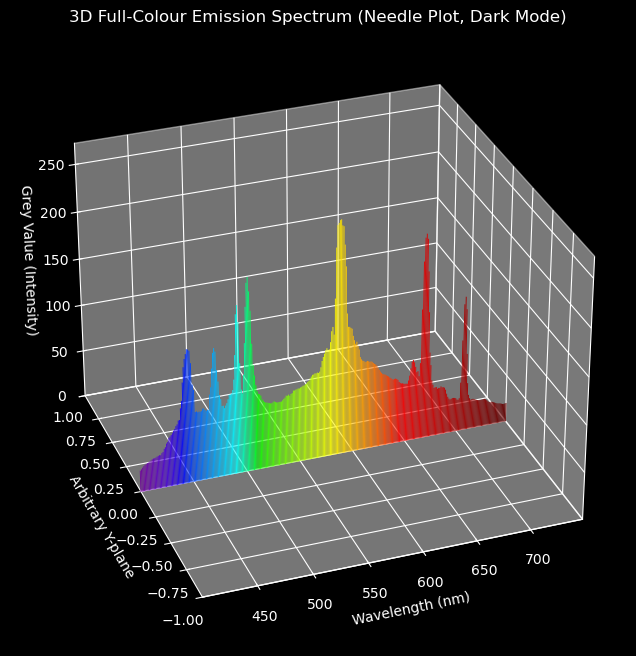

In [44]:
# Apply dark background style for better contrast
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.

x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

# For a 3D 'needle' plot, we want vertical lines originating from z=0.
# We can use a constant y-coordinate for a single spectrum.
y_constant = 0

# Plot each 'needle' individually
for i in range(len(x_wavelengths)): 
    ax.plot([x_wavelengths[i], x_wavelengths[i]], # x-coordinates for the line
            [y_constant, y_constant],           # y-coordinates for the line (constant)
            [0, z_intensity[i]],                # z-coordinates for the line (from 0 to intensity)
            color=spectral_colors[i], 
            linewidth=0.7, # Very thin line for the 'needle' effect
            alpha=0.9)

# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Arbitrary Y-plane', color='white') # Indicate a reference plane
ax.set_zlabel('Grey Value (Intensity)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Needle Plot, Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max())
ax.set_ylim(-1, 1) # Keep y-range small since it's a single plane
ax.set_zlim(0, z_intensity.max() * 1.1) # Some padding for intensity

# Adjust view angle for better perspective on the 'needles'
ax.view_init(elev=30, azim=-110) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


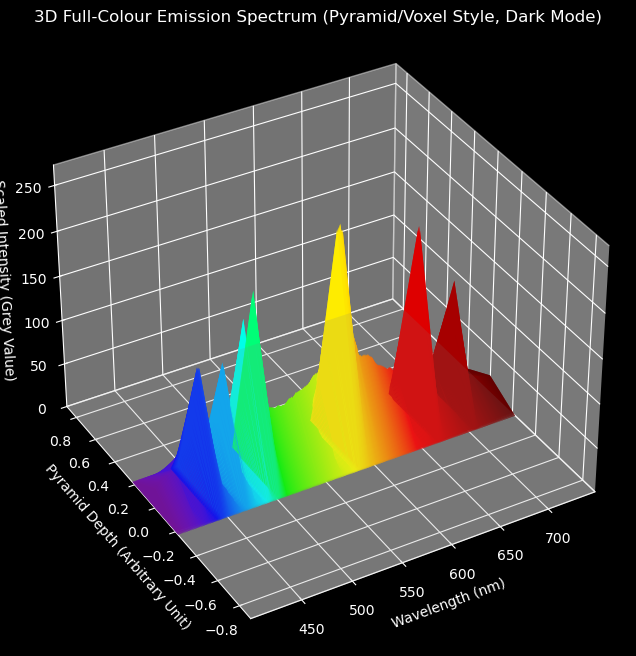

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Apply dark background style for better contrast
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.
x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

all_polygons = []
all_facecolors = []

# Parameters for the pyramid base
if len(x_wavelengths) > 1:
    avg_wavelength_step = np.mean(np.diff(x_wavelengths))
    base_size = avg_wavelength_step * 0.4 # Size of the pyramid base
else:
    base_size = 1.0

y_center = 0 # Y-coordinate for the center of the pyramid base

# Normalize intensity for pyramid height and potentially base size
max_intensity = z_intensity.max()
if max_intensity == 0:
    max_intensity = 1

# Scale heights for better visual representation
scaled_heights = (z_intensity / max_intensity) * max_intensity # Can adjust multiplier for visual scaling

for i in range(len(x_wavelengths)):
    x_val = x_wavelengths[i]
    z_val = scaled_heights[i]
    color = spectral_colors[i]

    if z_val > 0: # Only draw pyramids for non-zero intensity
        # Define the apex of the pyramid
        apex = [x_val, y_center, z_val]

        # Define the base vertices of the pyramid
        # These are points forming a square on the x-y plane at z=0
        base_v1 = [x_val - base_size/2, y_center - base_size/2, 0]
        base_v2 = [x_val + base_size/2, y_center - base_size/2, 0]
        base_v3 = [x_val + base_size/2, y_center + base_size/2, 0]
        base_v4 = [x_val - base_size/2, y_center + base_size/2, 0]

        # Define the 5 faces of the pyramid
        # Base face (square)
        face_base = [base_v1, base_v2, base_v3, base_v4]
        # Four triangular side faces
        face_side1 = [base_v1, base_v2, apex]
        face_side2 = [base_v2, base_v3, apex]
        face_side3 = [base_v3, base_v4, apex]
        face_side4 = [base_v4, base_v1, apex]

        all_polygons.extend([face_base, face_side1, face_side2, face_side3, face_side4])
        all_facecolors.extend([color] * 5) # Each pyramid has 5 faces, all same color

# Add all polygons to the 3D plot
ax.add_collection3d(Poly3DCollection(all_polygons, facecolors=all_facecolors, edgecolors='none', alpha=0.9))

# Add a subtle base plane for visual grounding
xx_plane, yy_plane = np.meshgrid(np.linspace(x_wavelengths.min() - base_size, x_wavelengths.max() + base_size, 2),
                                 np.linspace(y_center - base_size*2, y_center + base_size*2, 2))
zz_plane = np.zeros_like(xx_plane) # Flat plane at z=0
ax.plot_surface(xx_plane, yy_plane, zz_plane, alpha=0.15, color='gray', rstride=1, cstride=1, shade=False)

# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Pyramid Depth (Arbitrary Unit)', color='white')
ax.set_zlabel('Scaled Intensity (Grey Value)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Pyramid/Voxel Style, Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min() - base_size, x_wavelengths.max() + base_size)
ax.set_ylim(y_center - base_size*2, y_center + base_size*2)
ax.set_zlim(0, max_intensity * 1.1)

# Adjust view angle for better perspective on the pyramids
ax.view_init(elev=35, azim=-120) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')


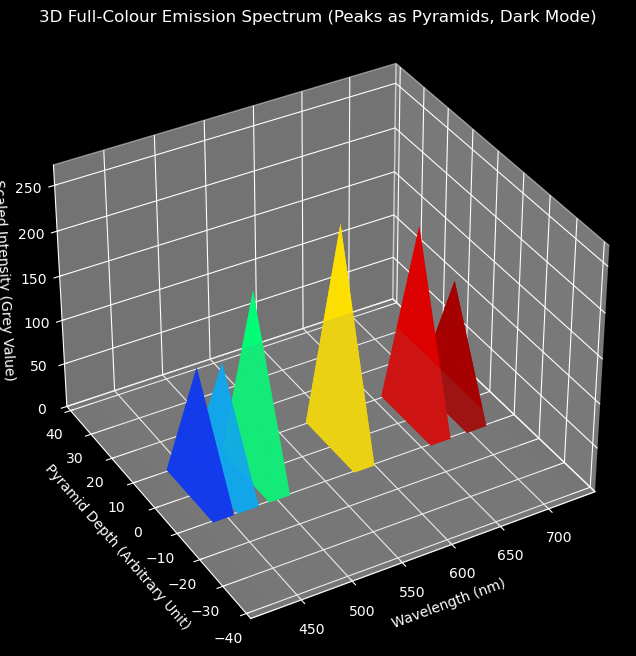

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.signal import find_peaks # Import find_peaks for peak detection

# Apply dark background style for better contrast
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.
x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# --- Peak Detection ---
# Find peaks in the intensity data.
# 'distance' parameter ensures that peaks are sufficiently separated.
# 'prominence' parameter filters out minor fluctuations and focuses on significant peaks.
peaks, _ = find_peaks(z_intensity, prominence=z_intensity.max() * 0.1, distance=10) # Adjust prominence/distance as needed

# Filter the data to include only the peaks
peak_wavelengths = x_wavelengths[peaks]
peak_intensity = z_intensity[peaks]
peak_colors = [spectral_colors[i] for i in peaks]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

all_polygons = []
all_facecolors = []

# Parameters for the pyramid base
if len(peak_wavelengths) > 1:
    # Calculate base size based on the average distance between peaks, or a fixed value
    avg_peak_wavelength_step = np.mean(np.diff(peak_wavelengths)) if len(peak_wavelengths) > 1 else 1.0
    base_size = avg_peak_wavelength_step * 0.4 # Size of the pyramid base
elif len(peak_wavelengths) == 1:
    base_size = 1.0 # Default for single peak
else:
    base_size = 0.5 # Fallback if no peaks found or very few

y_center = 0 # Y-coordinate for the center of the pyramid base

# Normalize intensity for pyramid height and potentially base size
max_intensity = peak_intensity.max() if len(peak_intensity) > 0 else 1
if max_intensity == 0:
    max_intensity = 1

# Scale heights for better visual representation
scaled_peak_heights = (peak_intensity / max_intensity) * max_intensity # Can adjust multiplier for visual scaling

for i in range(len(peak_wavelengths)):
    x_val = peak_wavelengths[i]
    z_val = scaled_peak_heights[i]
    color = peak_colors[i]

    if z_val > 0: # Only draw pyramids for non-zero intensity
        # Define the apex of the pyramid
        apex = [x_val, y_center, z_val]

        # Define the base vertices of the pyramid
        # These are points forming a square on the x-y plane at z=0
        base_v1 = [x_val - base_size/2, y_center - base_size/2, 0]
        base_v2 = [x_val + base_size/2, y_center - base_size/2, 0]
        base_v3 = [x_val + base_size/2, y_center + base_size/2, 0]
        base_v4 = [x_val - base_size/2, y_center + base_size/2, 0]

        # Define the 5 faces of the pyramid
        # Base face (square)
        face_base = [base_v1, base_v2, base_v3, base_v4]
        # Four triangular side faces
        face_side1 = [base_v1, base_v2, apex]
        face_side2 = [base_v2, base_v3, apex]
        face_side3 = [base_v3, base_v4, apex]
        face_side4 = [base_v4, base_v1, apex]

        all_polygons.extend([face_base, face_side1, face_side2, face_side3, face_side4])
        all_facecolors.extend([color] * 5) # Each pyramid has 5 faces, all same color

# Add all polygons to the 3D plot
ax.add_collection3d(Poly3DCollection(all_polygons, facecolors=all_facecolors, edgecolors='none', alpha=0.9))

# Add a subtle base plane for visual grounding
if len(peak_wavelengths) > 0:
    min_wl_peak, max_wl_peak = peak_wavelengths.min(), peak_wavelengths.max()
else:
    min_wl_peak, max_wl_peak = x_wavelengths.min(), x_wavelengths.max() # Use full range if no peaks

xx_plane, yy_plane = np.meshgrid(np.linspace(min_wl_peak - base_size, max_wl_peak + base_size, 2),
                                 np.linspace(y_center - base_size*2, y_center + base_size*2, 2))
zz_plane = np.zeros_like(xx_plane) # Flat plane at z=0
ax.plot_surface(xx_plane, yy_plane, zz_plane, alpha=0.15, color='gray', rstride=1, cstride=1, shade=False)

# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Pyramid Depth (Arbitrary Unit)', color='white')
ax.set_zlabel('Scaled Intensity (Grey Value)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Peaks as Pyramids, Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max()) # Use full wavelength range for context
ax.set_ylim(y_center - base_size*2, y_center + base_size*2)
ax.set_zlim(0, z_intensity.max() * 1.1) # Use full intensity range for context

# Adjust view angle for better perspective on the pyramids
ax.view_init(elev=35, azim=-120) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')

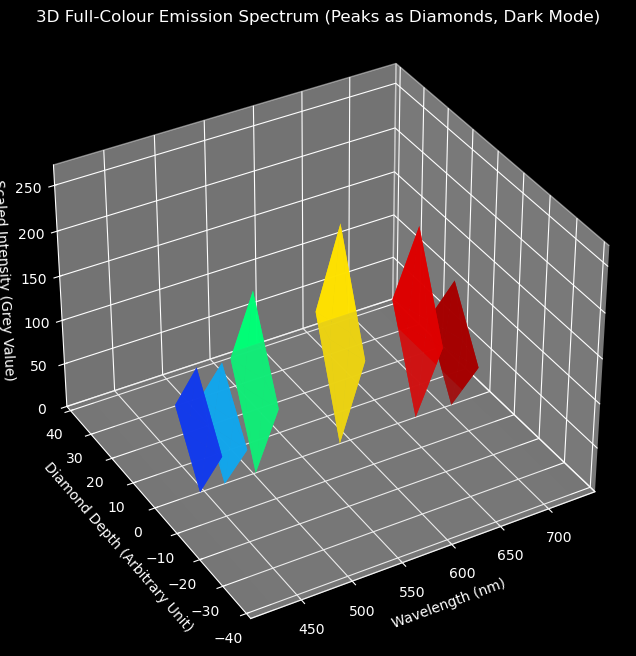

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.signal import find_peaks # Import find_peaks for peak detection

# Apply dark background style for better contrast
plt.style.use('dark_background')

# Assuming df_filtered and rgb are available from previous cells.
x_wavelengths = df_filtered['nm'].values # Wavelengths
z_intensity = df_filtered['Grey Val'].values # Grey Values (Intensity)

# Get the RGB colors for each wavelength
spectral_colors = [rgb(nm) for nm in x_wavelengths]

# --- Peak Detection ---
# Find peaks in the intensity data.
# 'distance' parameter ensures that peaks are sufficiently separated.
# 'prominence' parameter filters out minor fluctuations and focuses on significant peaks.
peaks, _ = find_peaks(z_intensity, prominence=z_intensity.max() * 0.1, distance=10) # Adjust prominence/distance as needed

# Filter the data to include only the peaks
peak_wavelengths = x_wavelengths[peaks]
peak_intensity = z_intensity[peaks]
peak_colors = [spectral_colors[i] for i in peaks]

# Create the 3D plot
fig = plt.figure(figsize=(15, 8))
ax = fig.add_subplot(111, projection='3d')

all_polygons = []
all_facecolors = []

# Parameters for the diamond base/width
if len(peak_wavelengths) > 1:
    # Calculate base size based on the average distance between peaks, or a fixed value
    avg_peak_wavelength_step = np.mean(np.diff(peak_wavelengths)) if len(peak_wavelengths) > 1 else 1.0
    base_size = avg_peak_wavelength_step * 0.4 # Size of the diamond's widest part
elif len(peak_wavelengths) == 1:
    base_size = 1.0 # Default for single peak
else:
    base_size = 0.5 # Fallback if no peaks found or very few

y_center = 0 # Y-coordinate for the center of the diamond

# Normalize intensity for diamond height
max_intensity = peak_intensity.max() if len(peak_intensity) > 0 else 1
if max_intensity == 0:
    max_intensity = 1

# Scale heights for better visual representation. The z_val will be the full height of the diamond.
scaled_peak_heights = (peak_intensity / max_intensity) * max_intensity # Can adjust multiplier for visual scaling

for i in range(len(peak_wavelengths)):
    x_val = peak_wavelengths[i]
    z_val = scaled_peak_heights[i]
    color = peak_colors[i]

    if z_val > 0: # Only draw diamonds for non-zero intensity
        # Define the vertices for an octahedron (diamond shape)
        # Top apex (at peak intensity)
        top_apex = [x_val, y_center, z_val]
        # Bottom apex (at z=0, the baseline)
        bottom_apex = [x_val, y_center, 0]

        # Middle layer vertices (equator of the diamond)
        # These points form a square in the x-y plane at z = z_val / 2
        v_x_plus = [x_val + base_size/2, y_center, z_val/2]
        v_x_minus = [x_val - base_size/2, y_center, z_val/2]
        v_y_plus = [x_val, y_center + base_size/2, z_val/2]
        v_y_minus = [x_val, y_center - base_size/2, z_val/2]

        # Define the 8 triangular faces of the octahedron
        # Upper 4 faces connecting to the top apex
        face1 = [top_apex, v_x_plus, v_y_plus]
        face2 = [top_apex, v_y_plus, v_x_minus]
        face3 = [top_apex, v_x_minus, v_y_minus]
        face4 = [top_apex, v_y_minus, v_x_plus]

        # Lower 4 faces connecting to the bottom apex
        face5 = [bottom_apex, v_y_plus, v_x_plus] # Reversed order for bottom to ensure consistent normal direction, if needed
        face6 = [bottom_apex, v_x_minus, v_y_plus]
        face7 = [bottom_apex, v_y_minus, v_x_minus]
        face8 = [bottom_apex, v_x_plus, v_y_minus]

        all_polygons.extend([face1, face2, face3, face4, face5, face6, face7, face8])
        all_facecolors.extend([color] * 8) # Each diamond has 8 faces, all same color

# Add all polygons to the 3D plot
ax.add_collection3d(Poly3DCollection(all_polygons, facecolors=all_facecolors, edgecolors='none', alpha=0.9))

# Add a subtle base plane for visual grounding
if len(peak_wavelengths) > 0:
    min_wl_peak, max_wl_peak = peak_wavelengths.min(), peak_wavelengths.max()
else:
    min_wl_peak, max_wl_peak = x_wavelengths.min(), x_wavelengths.max() # Use full range if no peaks

xx_plane, yy_plane = np.meshgrid(np.linspace(min_wl_peak - base_size, max_wl_peak + base_size, 2),
                                 np.linspace(y_center - base_size*2, y_center + base_size*2, 2))
zz_plane = np.zeros_like(xx_plane) # Flat plane at z=0
ax.plot_surface(xx_plane, yy_plane, zz_plane, alpha=0.15, color='gray', rstride=1, cstride=1, shade=False)

# Set labels and title
ax.set_xlabel('Wavelength (nm)', color='white')
ax.set_ylabel('Diamond Depth (Arbitrary Unit)', color='white')
ax.set_zlabel('Scaled Intensity (Grey Value)', color='white')
ax.set_title('3D Full-Colour Emission Spectrum (Peaks as Diamonds, Dark Mode)', color='white')

# Customize tick parameters for dark mode
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.tick_params(axis='z', colors='white')

# Set limits to ensure good viewing
ax.set_xlim(x_wavelengths.min(), x_wavelengths.max()) # Use full wavelength range for context
ax.set_ylim(y_center - base_size*2, y_center + base_size*2)
ax.set_zlim(0, z_intensity.max() * 1.1) # Use full intensity range for context

# Adjust view angle for better perspective on the diamonds
ax.view_init(elev=35, azim=-120) # Elevation and Azimuth angle

plt.show()

# Reset style to default after plotting to avoid affecting subsequent plots
plt.style.use('default')